# Import Packages

In [31]:
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\radhi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\radhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# IMPORT LIBRARIES

In [32]:
import numpy as np 
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# DATASET LOADING 

In [33]:
data_path = r'C:\Users\radhi\Downloads\archive\spam.csv'
df = pd.read_csv(data_path, encoding='latin-1')
# Display dataset 
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [34]:
#Display the shape of the dataset
print("shape of the dataset is : ")
print(df.shape)

shape of the dataset is : 
(5572, 5)


## DATA CLEANING

### Label Encoding 

In [35]:
# Isolate the target (v1) and the feature (v2) columns, dropping the unnamed NaN columns
df=df[['v1','v2']]
# Rename the columns to make them intuitive and highly readable
df.columns=['label', 'message']

# Display the first 5 rows of our cleaned DataFrame structure
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Checking for Missing Data 

In [36]:
df.isnull().sum()

label      0
message    0
dtype: int64

=> we have no missing values.

## Checking for duplicates 

In [37]:
df.duplicated().sum()

np.int64(403)

=> we have 403 duplicates. We need to remove those to ensure that the modl learns the true underlying patterns of spam rather than simply memorizing repeated text.

In [38]:
# Drop the duplicate rows, keeping only the first instance of each message
df=df.drop_duplicates(keep='first')
# Verify the new shape of the dataset to confirm duplicates were removed
print("New dataset shape")
print(df.shape)
# Inspect the distribution of our target labels to check for class imbalance
print("\n Class Distribution")
print(df['label'].value_counts())

New dataset shape
(5169, 2)

 Class Distribution
label
ham     4516
spam     653
Name: count, dtype: int64


=> We now do have 5169 unique text messages.The dataset indicates a significant class imbalance, with ham messages representing the majority class which is reasonalble since most people naturally receive more hams than spams.However while accuracy alone may not be a reliable evaluation of model performance eventually we should examine other evaluators like precision,recall ,F1-score and confusion matrix.

## Lowercasing

In [39]:
# Convert all characters in the 'message' column to lowercase
df['message']=df['message'].str.lower()
df.head()

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


## Removing Punctuation

In [40]:
# Use regular expressions to remove all punctuation
# r'[^\w\s]' matches anything that is NOT an alphanumeric character (\w) or whitespace (\s)
df['message'] = df['message'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

## Tokenization

In [41]:
# Apply the word_tokenize function to split each message into a list of individual words
df['tokens']=df['message'].apply(word_tokenize)
print(df[['message','tokens']])

                                                message  \
0     go until jurong point crazy available only in ...   
1                               ok lar joking wif u oni   
2     free entry in 2 a wkly comp to win fa cup fina...   
3           u dun say so early hor u c already then say   
4     nah i dont think he goes to usf he lives aroun...   
...                                                 ...   
5567  this is the 2nd time we have tried 2 contact u...   
5568               will ì_ b going to esplanade fr home   
5569  pity  was in mood for that soany other suggest...   
5570  the guy did some bitching but i acted like id ...   
5571                          rofl its true to its name   

                                                 tokens  
0     [go, until, jurong, point, crazy, available, o...  
1                        [ok, lar, joking, wif, u, oni]  
2     [free, entry, in, 2, a, wkly, comp, to, win, f...  
3     [u, dun, say, so, early, hor, u, c, already, t...  
4

## Removing Stopwords

In [42]:
# Store the English stopwords in a set for much faster processing
stop_words= set(stopwords.words('english'))
# Apply a filter to keep only the tokens that are NOT in our stop_words list
df['tokens']=df['tokens'].apply(lambda x: [ word for word in x if word not in stop_words])
print (df['tokens'].head())

0    [go, jurong, point, crazy, available, bugis, n...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, 2, wkly, comp, win, fa, cup, fin...
3        [u, dun, say, early, hor, u, c, already, say]
4    [nah, dont, think, goes, usf, lives, around, t...
Name: tokens, dtype: object


## Stemming 

In [43]:
ps= PorterStemmer()
# Apply the stemmer to chop off prefixes/suffixes and find the root stem
df['tokens']=df['tokens'].apply(
    lambda words : [ps.stem (word) for word in words]
)
df.head()

,label,message,tokens
0,ham,go until jurong point crazy available only in ...,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,ok lar joking wif u oni,"[ok, lar, joke, wif, u, oni]"
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,u dun say so early hor u c already then say,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,nah i dont think he goes to usf he lives aroun...,"[nah, dont, think, goe, usf, live, around, tho..."


## Rejoining Tokens into Text

In [44]:
df['processed_messages']=df['tokens'].apply(lambda x:' '.join(x))
df[['tokens','processed_messages']].head()

,tokens,processed_messages
0,"[go, jurong, point, crazi, avail, bugi, n, gre...",go jurong point crazi avail bugi n great world...
1,"[ok, lar, joke, wif, u, oni]",ok lar joke wif u oni
2,"[free, entri, 2, wkli, comp, win, fa, cup, fin...",free entri 2 wkli comp win fa cup final tkt 21...
3,"[u, dun, say, earli, hor, u, c, alreadi, say]",u dun say earli hor u c alreadi say
4,"[nah, dont, think, goe, usf, live, around, tho...",nah dont think goe usf live around though


## Save the Cleaned Data

In [45]:
# Save our final dataframe to a CSV file.
# We set index=False so Pandas doesn't create a useless column of row numbers!
df.to_csv('cleaned_spam_data.csv', index= False)

# Feature Extraction

In [46]:
df = pd.read_csv('cleaned_spam_data.csv')
df['processed_messages']= df['processed_messages'].fillna('')
df.head()

,label,message,tokens,processed_messages
0,ham,go until jurong point crazy available only in ...,"['go', 'jurong', 'point', 'crazi', 'avail', 'b...",go jurong point crazi avail bugi n great world...
1,ham,ok lar joking wif u oni,"['ok', 'lar', 'joke', 'wif', 'u', 'oni']",ok lar joke wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"['free', 'entri', '2', 'wkli', 'comp', 'win', ...",free entri 2 wkli comp win fa cup final tkt 21...
3,ham,u dun say so early hor u c already then say,"['u', 'dun', 'say', 'earli', 'hor', 'u', 'c', ...",u dun say earli hor u c alreadi say
4,ham,nah i dont think he goes to usf he lives aroun...,"['nah', 'dont', 'think', 'goe', 'usf', 'live',...",nah dont think goe usf live around though


In [47]:
# Import the CountVectorizer tool from scikit-learn to build our Bag of Words
from sklearn.feature_extraction.text import CountVectorizer
# Initialize the vectorizer object
cv = CountVectorizer()
# Fit the vectorizer to our cleaned text and transform it into a numerical matrix
X_bow = cv.fit_transform(df['processed_messages'])
# Print the shape of the matrix to see the number of text messages and unique words
print("Matrix Shape:")
print(X_bow.shape)

# Display the first 20 unique words the vectorizer learned for its master vocabulary
print("\nFirst 20 Vocabulary Words:")
print(cv.get_feature_names_out()[:20])

Matrix Shape:
(5169, 8065)

First 20 Vocabulary Words:
['008704050406' '0089mi' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '02073162414'
 '02085076972' '020903' '021' '050703' '0578' '06' '060505' '061104']


In [48]:
print(X_bow.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize the vectorizer and limit our vocabulary to the top 3000 most important words
tfidf = TfidfVectorizer(max_features=3000)
# Fit the vectorizer to our cleaned text and transform it into a weighted numerical matrix
X = tfidf.fit_transform(df['processed_messages'])
# Print the shape to verify our rows of text messages and our 3000 vocabulary words
print("TF-IDF Matrix Shape:")
print(X.shape)

# Display a sample of the first 20 unique words the vectorizer chose for the vocabulary
print("\nFirst 20 TF-IDF Vocabulary Words:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF Matrix Shape:
(5169, 3000)

First 20 TF-IDF Vocabulary Words:
['008704050406' '020603' '0207' '02073162414' '020903' '021' '050703'
 '0578' '071104' '07123456789' '0776xxxxxxx' '07xxxxxxxxx' '0800'
 '08000839402' '08000930705' '08001950382' '08002986906' '0845' '0870'
 '08701417012']


### Encoding the Target Label

In [50]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

In [51]:
import numpy as np
import scipy.sparse 

# 1. Save the encoded labels (y)
np.save('y_encoded.npy', y)

# 2. Save the TF-IDF features (X) 
# Note: Because X is a massive, sparse mathematical matrix, we use SciPy to save it efficiently.
scipy.sparse.save_npz('X_features.npz', X)

print("Success! Features and labels saved for the modeling stage.")

Success! Features and labels saved for the modeling stage.


# Modeling with XGBoost

In [52]:
# Load the labels and features
y = np.load('y_encoded.npy')
X = scipy.sparse.load_npz('X_features.npz')

# Quick check to ensure the shapes match (Rows in X should equal items in y)
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print("Data loaded successfully! Ready to train XGBoost.")


Features shape: (5169, 3000)
Labels shape: (5169,)
Data loaded successfully! Ready to train XGBoost.


### Data Splitting

In [53]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the dimensions of our new datasets
print("--- Training Data Shape ---")
print(X_train.shape)
print("\n--- Testing Data Shape ---")
print(X_test.shape)

--- Training Data Shape ---
(4135, 3000)

--- Testing Data Shape ---
(1034, 3000)


In [54]:

!pip install xgboost

from xgboost import XGBClassifier

# Initialize the model with parameters to equalize class imbalance, guarantee reproducible results, and suppress logging warnings
model = XGBClassifier(scale_pos_weight= 2,random_state=42, eval_metric='logloss')

# Train the model using our practice data
model.fit(X_train, y_train)

Defaulting to user installation because normal site-packages is not writeable


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [55]:
# Use the trained model to predict labels for the test set
y_pred = model.predict(X_test)

# Display the first 10 predictions (0 = Ham, 1 = Spam)
print("--- First 10 Predictions ---")
print(y_pred[:10])

--- First 10 Predictions ---
[0 0 0 0 0 1 0 1 0 0]


In [56]:
import numpy as np
import joblib

# 1. Save the trained XGBoost model
joblib.dump(model, 'xgboost_spam_model.pkl')

# 2. Save the actual answers and the model's predictions
np.save('y_test.npy', y_test)
np.save('y_pred.npy', y_pred)

print("Success! Model and predictions saved for the final evaluation.")

Success! Model and predictions saved for the final evaluation.


# Model Evaluation

In [60]:
import joblib

# Load the actual answers and model predictions
y_test = np.load('y_test.npy')
y_pred = np.load('y_pred.npy')

# Load the trained XGBoost model
model = joblib.load('xgboost_spam_model.pkl')

print("Data and model loaded successfully! Ready to evaluate performance.")

Data and model loaded successfully! Ready to evaluate performance.


## Confusion Matrix

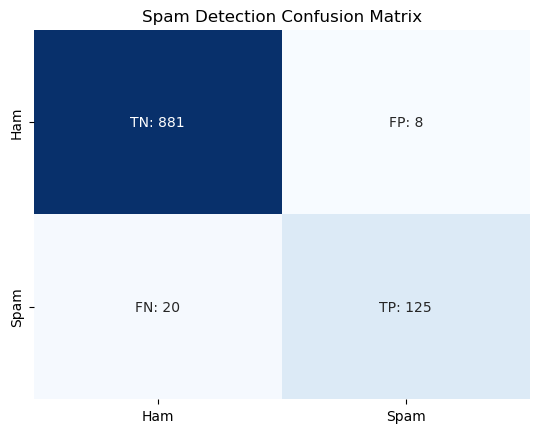

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the matrix and define the labels in a compact format
cm = confusion_matrix(y_test, y_pred)
labels = [[f"TN: {cm[0,0]}", f"FP: {cm[0,1]}"], [f"FN: {cm[1,0]}", f"TP: {cm[1,1]}"]]

# Plot the heatmap
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
plt.title('Spam Detection Confusion Matrix')
plt.show()

## Accuracy

In [62]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy by comparing our pre-loaded predictions to the true answers
test_accuracy = accuracy_score(y_test, y_pred)

# Print the final score formatted as a percentage
print("Test Accuracy:", test_accuracy)


Test Accuracy: 0.9729206963249516


In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate and print the advanced classification metrics
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

Precision: 0.9398496240601504
Recall:    0.8620689655172413
F1 Score:  0.8992805755395683


=> 